In [ ]:
import pathlib
import types

In [ ]:
import marimo as mo
from matplotlib import pyplot as plt
import pandas as pd
import requests
from scipy import stats as scipy_stats
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from teeplot import teeplot as tp
from watermark import watermark

In [ ]:
from conduitpylib.wrangle import (
    retrieve_and_prepare_delta_dataframes,
    wrangle_instrumentation_longform,
)

In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-05-27T20:54:40.996103+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1052-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

matplotlib : 3.9.2
requests   : 2.34.2
marimo     : 0.23.2
statsmodels: 0.14.6
pandas     : 2.2.3
seaborn    : 0.13.2
scipy      : 1.14.1
teeplot    : 1.4.2

```

## Prep Data

In [ ]:
def apply(df: pd.DataFrame) -> pd.DataFrame:
    def row_distiller(row):
        return {
            k: v
            for k, v in row.items()
            if k in ("Num Nodes", "Num Processes")
        }

    df["Multiprocessing"] = df.apply(
        lambda row: {
            frozenset(
                {"Num Nodes": 1, "Num Processes": 2}.items()
            ): "Intranode",
            frozenset(
                {"Num Nodes": 2, "Num Processes": 2}.items()
            ): "Internode",
        }[frozenset(row_distiller(row).items())],
        axis=1,
    )
    return df

with open("/tmp/4ys9v", "wb") as fp:
    fp.write(
        requests.get(
            "https://osf.io/download/4ys9v", allow_redirects=True
        ).content,
    )

with open("/tmp/aum7w", "wb") as fp:
    fp.write(
        requests.get(
            "https://osf.io/download/aum7w", allow_redirects=True
        ).content,
    )

longitudinal_df, snapshot_df = retrieve_and_prepare_delta_dataframes(
    df_inlet_url="/tmp/4ys9v",
    df_outlet_url="/tmp/aum7w",
    apply=apply,
    treatment_column="Multiprocessing",
)

a: df_inlet
digest: 72b73f464356a0344770f538ac30ceb94310fff95955aa728e2a3562a8504f68
num cols: 42
num cols all na: 2
num cols any na: 42
num na: 1102
num rows: 521
num rows all na: 1
num rows any na: 521
size: 407K

a: df_outlet
digest: c2accc805a9ab23eb0bf04fad355098a539bd24ad75272fa18c53a8a45f917a8
num cols: 68
num cols all na: 6
num cols any na: 68
num na: 3220
num rows: 521
num rows all na: 1
num rows any na: 521
size: 514K

df_inlet has 1 na rows, dropping them
df_outlet has 1 na rows, dropping them


In [ ]:
data = wrangle_instrumentation_longform(
    longitudinal_df=longitudinal_df,
    snapshot_df=snapshot_df,
)
data

,Process Instance UUID,Snapshot,Async Mode,Num Nodes,Allocated Tasks Per Node,Cpus Per Node,Num Processes,Log Num Processes,Num Simels Per Cpu,Replicate,...,Num Tasks,Num Cpus,Delivery Time Inlet,Delivery Time Outlet,Inlet-Seconds Elapsed,Outlet-Seconds Elapsed,Simstep Period Inlet (s),Simstep Period Outlet (s),Latency Walltime Inlet (s),Latency Walltime Outlet (s)
1,01555a4e-cae8-4535-af65-469bcb27bb46,1,3,1,2,2,2,0.5,1.0,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,09a530f8-0432-47e7-aee9-c6e37f653ea9,2,3,1,2,2,2,0.5,1.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,0af8dd71-0a9b-4b14-95a5-169484929c74,4,3,1,2,2,2,0.5,1.0,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,1cde3987-79d0-46cf-9a16-ddef7e792aea,0,3,1,2,2,2,0.5,1.0,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29,1e0d9afe-c298-4791-9aee-24535100a141,5,3,1,2,2,2,0.5,1.0,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
467,dce2689a-7ea7-4fc6-868c-4ef67cf3125f,6,3,2,1,1,2,0.5,1.0,2,...,2.0,2.0,15.991867,15.991867,330.0,330.0,0.000009,0.000009,0.000147,0.000147
480,e164a965-1dd2-4742-ae15-90c1d951a8f2,6,3,1,2,2,2,0.5,1.0,1,...,2.0,2.0,0.510645,0.510645,330.0,330.0,0.000005,0.000005,0.000003,0.000003
493,e8638be7-3a70-4634-abb0-2f634ae894f4,6,3,2,1,1,2,0.5,1.0,5,...,2.0,2.0,17.740106,17.740106,331.0,331.0,0.000008,0.000008,0.000147,0.000147
506,f36a89f7-e37a-4c80-bbe0-af5ca0ab24b8,6,3,2,1,1,2,0.5,1.0,3,...,2.0,2.0,18.862458,18.862458,330.0,330.0,0.000008,0.000008,0.000147,0.000147


In [ ]:
data["Hostname"].unique()

array(['lac-361', 'lac-221', 'lac-220'], dtype=object)

In [ ]:
data_ = data.copy().reset_index(drop=True)
data_["indexx"] = data_.index
df_long = data_.melt(
    id_vars=[
        "Instrumentation",
        "Multiprocessing",
        "indexx",
        "Execution Instance UUID",
        "Hostname",
        "proc",
        "Replicate",
    ],
    value_vars=[
        "Messages Received Per Second",
        "Messages Sent Per Second",
    ],
    var_name="Message Type",
    value_name="Count Per Second",
)
df_long["Type"] = pd.Categorical(
    df_long["Message Type"].replace(
        {
            "Messages Sent Per Second": "Sent        ",
            "Messages Received Per Second": "        Recv",
        },
    ),
    categories=["        Recv", "Sent        "],
    ordered=True,
)

In [ ]:
palette = {
    "lac-361": "#EFB743",
    "lac-221": "#E72F52",
    "lac-220": "#0D95D0",
}

## Helpers

In [ ]:
# # adapted from https://stackoverflow.com/a/47381719/17332200
def bottom_offset(self, bboxes, bboxes2):
    pad = (
        plt.rcParams["xtick.major.size"] + plt.rcParams["xtick.major.pad"]
    )
    self.offsetText.set(va="top", ha="left")
    _oy = self.axes.bbox.ymin - pad * self.figure.dpi / 72.0
    self.offsetText.set_position((1, _oy))

## Example Plot

teeplots/2026-05-15-mp-vs-mt-beleagurement/hue=multiprocessing+viz=lmplot+x=messages-received-per-second+y=messages-sent-per-second+ext=.pdf
teeplots/2026-05-15-mp-vs-mt-beleagurement/hue=multiprocessing+viz=lmplot+x=messages-received-per-second+y=messages-sent-per-second+ext=.png


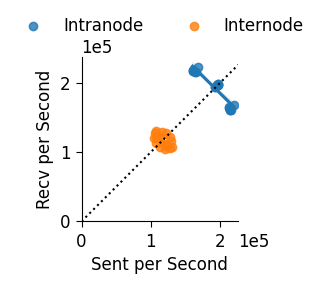

In [ ]:
with tp.teed(
    sns.lmplot,
    data=data[data["Instrumentation"] == "Longitudinal"],
    x="Messages Received Per Second",
    y="Messages Sent Per Second",
    hue="Multiprocessing",
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as _g:
    _ax = _g.axes.flat[0]
    sns.move_legend(
        _g,
        "lower center",
        bbox_to_anchor=(0.5, 1),
        ncol=2,
        title=None,
        frameon=False,
    )
    _g.set(xlabel="Sent per Second", ylabel="Recv per Second")
    _g.set(xlim=(0, None), ylim=(0, None))
    _g.figure.set_size_inches(5, 2)
    _ax.set_aspect("equal", adjustable="box")
    plt.ticklabel_format(axis="both", style="sci", scilimits=(0, 0))
    _ax.axline((0, 0), (1, 1), color="k", ls=":")
    _ax.xaxis.get_offset_text().offset_text_position = "top"

    # adapted from https://stackoverflow.com/a/47381719/17332200
    _ax.xaxis._update_offset_text_position = types.MethodType(
        bottom_offset, _ax.xaxis
    )

teeplots/2026-05-15-mp-vs-mt-beleagurement/hue=multiprocessing+viz=lmplot+x=messages-received-per-second+y=num-try-puts-attempted+ext=.pdf
teeplots/2026-05-15-mp-vs-mt-beleagurement/hue=multiprocessing+viz=lmplot+x=messages-received-per-second+y=num-try-puts-attempted+ext=.png


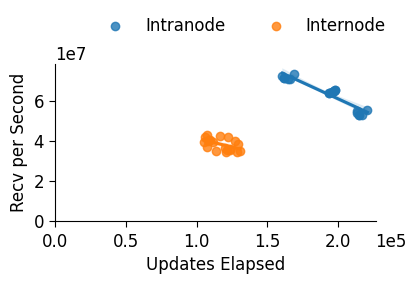

In [ ]:
with tp.teed(
    sns.lmplot,
    data=data[data["Instrumentation"] == "Longitudinal"],
    x="Messages Received Per Second",
    y="Num Try Puts Attempted",
    hue="Multiprocessing",
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as _g:
    _ax = _g.axes.flat[0]
    sns.move_legend(
        _g,
        "lower center",
        bbox_to_anchor=(0.5, 1),
        ncol=2,
        title=None,
        frameon=False,
    )
    _g.set(xlabel="Updates Elapsed", ylabel="Recv per Second")
    _g.set(xlim=(0, None), ylim=(0, None))
    _g.figure.set_size_inches(5, 2)
    plt.ticklabel_format(axis="both", style="sci", scilimits=(0, 0))
    _ax.xaxis.get_offset_text().offset_text_position = "top"
    _ax.xaxis._update_offset_text_position = types.MethodType(
        bottom_offset, _ax.xaxis
    )

In [ ]:
replicates = data[data["Messages Received Per Second"] > 2e5]["Replicate"]
replicates

,Replicate
25,0
64,7
77,2
103,5
142,8
363,3


teeplots/2026-05-15-mp-vs-mt-beleagurement/col=multiprocessing+hue=hostname+kind=line+style=indexx+viz=relplot+x=type+y=count-per-second+ext=.pdf
teeplots/2026-05-15-mp-vs-mt-beleagurement/col=multiprocessing+hue=hostname+kind=line+style=indexx+viz=relplot+x=type+y=count-per-second+ext=.png


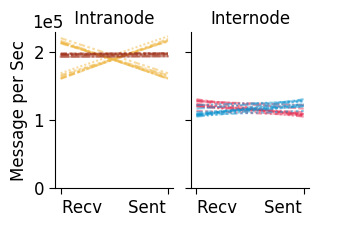

In [ ]:
df_long["special"] = df_long["Replicate"].isin([1, 4, 6, 9])
with tp.teed(
    sns.relplot,
    data=df_long[df_long["Instrumentation"] == "Longitudinal"],
    x="Type",
    y="Count Per Second",
    col="Multiprocessing",
    col_order=[" Intranode ", "Internode"],
    style="indexx",
    hue="Hostname",
    alpha=0.5,
    kind="line",
    legend=False,
    palette=palette,
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as _g:
    _ax = _g.axes.flat[0]
    sns.lineplot(
        data=df_long[
            (df_long["Instrumentation"] == "Longitudinal")
            & (df_long["Multiprocessing"] == "Intranode")
        ],
        x="Type",
        y="Count Per Second",
        style="indexx",
        hue="special",
        alpha=0.5,
        ax=_ax,
        legend=False,
        palette=["#EFB743", "#A1331C"],
    )
    _g.set_titles(template="{col_name}")
    _g.set(ylim=(0, None), ylabel="Message per Sec", xlabel=None)
    plt.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    _g.figure.set_size_inches(3, 2)
    _ax.yaxis.get_offset_text().set_x(-0.2)

In [ ]:
_data = data[
    (data["Instrumentation"] == "Longitudinal")
    & (data["Multiprocessing"] == "Intranode")
]
_data["received"] = _data["Messages Received Per Second"]
_data["sent"] = _data["Messages Sent Per Second"]

_model = smf.glm(
    formula="sent ~ received", data=_data, family=sm.families.Gaussian()
).fit()

print(_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   sent   No. Observations:                   20
Model:                            GLM   Df Residuals:                       18
Model Family:                Gaussian   Df Model:                            1
Link Function:               Identity   Scale:                      5.8873e+07
Method:                          IRLS   Log-Likelihood:                -206.23
Date:                Wed, 27 May 2026   Deviance:                   1.0597e+09
Time:                        20:54:49   Pearson chi2:                 1.06e+09
No. Iterations:                     3   Pseudo R-squ. (CS):             0.9989
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   3.825e+05   1.63e+04     23.533      0.0

teeplots/2026-05-15-mp-vs-mt-beleagurement/hue=hostname+kind=box+viz=catplot+x=hostname+y=updates-per-second+ext=.pdf
teeplots/2026-05-15-mp-vs-mt-beleagurement/hue=hostname+kind=box+viz=catplot+x=hostname+y=updates-per-second+ext=.png


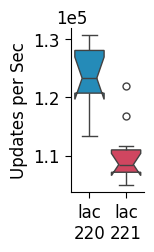

Hostname,lac-220,lac-221
Execution Instance UUID,,
5e1df980-374e-45c6-bb11-6be2fcd08e01,120588.815152,105018.054545
67985d4a-823a-4a80-819d-6adc59a9b7aa,130670.836364,107121.784848
8ca011c2-b0a9-465e-84b2-ef007fda797f,121064.700906,108383.175758
a6d981af-2329-4917-92d0-b76472d301f7,129052.054545,116754.284848
b2e63bda-3e4a-43e2-899a-da3378230d22,123239.221212,109123.851515
b6b3ad38-4707-489e-8099-2a4f038844fd,127270.627273,121971.012121
bcfea1a5-b11b-4446-8f22-2bf57d32f800,113356.184848,107186.854545
bf81faa0-5108-4e0e-ab07-8e8794ccca18,123290.815152,108541.618182
c732e704-4c4a-4565-b93c-ebb9e49c8820,128282.148485,105828.627273


In [ ]:
data["Updates per Second"] = 1 / data["Simstep Period Inlet (s)"]
_data = data[
    (data["Instrumentation"] == "Longitudinal")
    & (data["Multiprocessing"] == "Internode")
]
with tp.teed(
    sns.catplot,
    data=_data,
    y="Updates per Second",
    hue="Hostname",
    x="Hostname",
    kind="box",
    legend=False,
    notch=True,
    order=["lac-220", "lac-221"],
    palette=palette,
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as _g:
    _ax = _g.axes.flat[0]
    _g.set_titles(template="{col_name}")
    _g.set(ylabel="Updates per Sec", xlabel=None)
    plt.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    _g.figure.set_size_inches(1, 2)
    _ax.yaxis.get_offset_text().set_x(-0.2)
    _ax.set_xticklabels(["lac\n220", "lac\n221"])

_pivot = _data.pivot(
    index="Execution Instance UUID",
    columns="Hostname",
    values="Updates per Second",
)

for x in [
    _pivot,
    _pivot.mean(),
    _pivot.std(),
    scipy_stats.wilcoxon(_pivot["lac-221"], _pivot["lac-220"]),
]:
    mo.output.append(x)

teeplots/2026-05-15-mp-vs-mt-beleagurement/hue=hostname+kind=box+viz=catplot+x=hostname+y=ms-per-update+ext=.pdf
teeplots/2026-05-15-mp-vs-mt-beleagurement/hue=hostname+kind=box+viz=catplot+x=hostname+y=ms-per-update+ext=.png


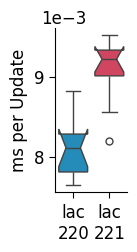

Hostname,lac-220,lac-221
Execution Instance UUID,,
5e1df980-374e-45c6-bb11-6be2fcd08e01,0.008293,0.009522
67985d4a-823a-4a80-819d-6adc59a9b7aa,0.007653,0.009335
8ca011c2-b0a9-465e-84b2-ef007fda797f,0.008260,0.009227
a6d981af-2329-4917-92d0-b76472d301f7,0.007749,0.008565
b2e63bda-3e4a-43e2-899a-da3378230d22,0.008114,0.009164
b6b3ad38-4707-489e-8099-2a4f038844fd,0.007857,0.008199
bcfea1a5-b11b-4446-8f22-2bf57d32f800,0.008822,0.009330
bf81faa0-5108-4e0e-ab07-8e8794ccca18,0.008111,0.009213
c732e704-4c4a-4565-b93c-ebb9e49c8820,0.007795,0.009449


In [ ]:
data["ms per Update"] = data["Simstep Period Inlet (s)"] * 1000
_data2 = data[
    (data["Instrumentation"] == "Longitudinal")
    & (data["Multiprocessing"] == "Internode")
]
with tp.teed(
    sns.catplot,
    data=_data2,
    y="ms per Update",
    hue="Hostname",
    x="Hostname",
    kind="box",
    legend=False,
    notch=True,
    order=["lac-220", "lac-221"],
    palette=palette,
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as _g:
    _ax = _g.axes.flat[0]
    _g.set_titles(template="{col_name}")
    _g.set(ylabel="ms per Update", xlabel=None)
    plt.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    _g.figure.set_size_inches(1, 2)
    _ax.yaxis.get_offset_text().set_x(-0.2)
    _ax.set_xticklabels(["lac\n220", "lac\n221"])

_pivot2 = _data2.pivot(
    index="Execution Instance UUID",
    columns="Hostname",
    values="ms per Update",
)

for _x in [
    _pivot2,
    _pivot2.mean(),
    _pivot2.std(),
    scipy_stats.wilcoxon(_pivot2["lac-221"], _pivot2["lac-220"]),
]:
    mo.output.append(_x)

In [ ]:
_data = data[
    (data["Instrumentation"] == "Longitudinal")
    & (data["Multiprocessing"] == "Internode")
]
_data["received"] = _data["Messages Received Per Second"]
_data["sent"] = _data["Messages Sent Per Second"]

_model = smf.glm(
    formula="sent ~ received",
    data=_data,
    family=sm.families.Gaussian(),
).fit()

print(_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   sent   No. Observations:                   20
Model:                            GLM   Df Residuals:                       18
Model Family:                Gaussian   Df Model:                            1
Link Function:               Identity   Scale:                      5.6855e+07
Method:                          IRLS   Log-Likelihood:                -205.89
Date:                Wed, 27 May 2026   Deviance:                   1.0234e+09
Time:                        20:54:49   Pearson chi2:                 1.02e+09
No. Iterations:                     3   Pseudo R-squ. (CS):             0.2972
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.784e+05   2.34e+04      7.625      0.0

In [ ]:
_data = data[
    (data["Instrumentation"] == "Longitudinal")
    & (data["Multiprocessing"] == "Internode")
]
_data["received"] = _data["Messages Received Per Second"]
_data["sent"] = _data["Messages Sent Per Second"]

_model = smf.glm(
    formula="sent ~ received + C(Hostname)",
    data=_data,
    family=sm.families.Gaussian(),
).fit()

print(_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   sent   No. Observations:                   20
Model:                            GLM   Df Residuals:                       17
Model Family:                Gaussian   Df Model:                            2
Link Function:               Identity   Scale:                      2.6421e+07
Method:                          IRLS   Log-Likelihood:                -197.65
Date:                Wed, 27 May 2026   Deviance:                   4.4915e+08
Time:                        20:54:49   Pearson chi2:                 4.49e+08
No. Iterations:                     3   Pseudo R-squ. (CS):             0.8422
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept               8.70